**Name:** Zainab Sarfraz

**Assigned Track:** Data Science

**Task Title:** Industrial Training Kit


**Imported Libraries:** In this step, we import the necessary Python libraries required for data preprocessing, dimensionality reduction, clustering, and evaluation.

- Pandas and NumPy are used for data manipulation and numerical operations.
- Matplotlib is used for data visualization.
- StandardScaler is used to standardize features.
- PCA is used for dimensionality reduction.
- K-Means is used to segment customers into clusters.
- Silhouette Score is used to evaluate the quality of the clusters.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
print('done') 

done


**Loading the Dataset:** In this step, we load the customer dataset for analysis.

In [3]:
df = pd.read_csv('E:\\National Textile University\\internship at decode labs\\week3\\Customer Personality Analysis.csv')

In [4]:
df.head(2)

,ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse
0,5524\t1957\tGraduation\tSingle\t58138\t0\t0\t0...
1,2174\t1954\tGraduation\tSingle\t46344\t1\t1\t0...


In [5]:
df.describe()

,ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse
count,2240
unique,2240
top,5524\t1957\tGraduation\tSingle\t58138\t0\t0\t0...
freq,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                    Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                                                                                                                                                                    --------------  ----- 
 0   ID	Year_Birth	Education	Marital_Status	Income	Kidhome	Teenhome	Dt_Customer	Recency	MntWines	MntFruits	MntMeat

In [7]:
df.columns

Index(['ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse'], dtype='object')

**Checking Missing Values:** We check for missing values because they can cause problems during analysis and machine learning.

In [8]:
df.isnull().sum()

ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse    0
dtype: int64

In [10]:
df.isnull().sum().sum()

0

In [11]:
df.duplicated().sum()

0

In [12]:
df.drop_duplicates()

,ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse
0,5524\t1957\tGraduation\tSingle\t58138\t0\t0\t0...
1,2174\t1954\tGraduation\tSingle\t46344\t1\t1\t0...
2,4141\t1965\tGraduation\tTogether\t71613\t0\t0\...
3,6182\t1984\tGraduation\tTogether\t26646\t1\t0\...
4,5324\t1981\tPhD\tMarried\t58293\t1\t0\t19-01-2...
...,...
2235,10870\t1967\tGraduation\tMarried\t61223\t0\t1\...
2236,4001\t1946\tPhD\tTogether\t64014\t2\t1\t10-06-...
2237,7270\t1981\tGraduation\tDivorced\t56981\t0\t0\...
2238,8235\t1956\tMaster\tTogether\t69245\t0\t1\t24-...


**Exploring the Dataset:** We check the shape and basic information of the dataset to understand its structure.

In [13]:
df.shape

(2240, 1)

**Removing Customer ID:** The ID column is removed because it is only an identifier and does not provide useful information for customer segmentation.

In [14]:
x = df.drop(columns = ['ID'], errors = 'ignore')
print(x)

     ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse
0     5524\t1957\tGraduation\tSingle\t58138\t0\t0\t0...                                                                                                                                                                                                                                                                                                                                                  
1     2174\t1954\tGraduation\tSingle\t46344\t1\t1\t0...                                                                                                                                                             

In [15]:
x = df.select_dtypes(include=[np.number])
print(x)

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[2240 rows x 0 columns]


**Encoding Categorical Data:** Categorical columns are converted into numerical values so that machine learning algorithms can process them.

In [16]:
x = df.copy()
x = pd.get_dummies(df, drop_first=True)
print(x)
print(x.shape)

      ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse_1\t1961\tGraduation\tSingle\t57091\t0\t0\t15-06-2014\t0\t464\t5\t64\t7\t0\t37\t1\t7\t3\t7\t5\t0\t0\t0\t0\t1\t0\t3\t11\t1  \
0                                                 False                                                                                                                                                                                                                                                                                                                                                                                                                                          

**Feature Scaling:** The features are scaled so that all variables have a similar range and contribute fairly to distance-based clustering.

In [17]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
print(x_scaled)

[[-0.02113357 -0.02113357 -0.02113357 ... -0.02113357 -0.02113357
  -0.02113357]
 [-0.02113357 -0.02113357 -0.02113357 ... -0.02113357 -0.02113357
  -0.02113357]
 [-0.02113357 -0.02113357 -0.02113357 ... -0.02113357 -0.02113357
  -0.02113357]
 ...
 [-0.02113357 -0.02113357 -0.02113357 ... -0.02113357 -0.02113357
  -0.02113357]
 [-0.02113357 -0.02113357 -0.02113357 ... -0.02113357 -0.02113357
  -0.02113357]
 [-0.02113357 -0.02113357 -0.02113357 ... -0.02113357 -0.02113357
  -0.02113357]]


**Handling Missing Values:** Missing values are filled with the median value to prepare the data for further analysis.

In [18]:
print(x.isnull().sum().sum())
print(x.fillna(x.median(), inplace=True))

0
None


In [20]:
print("infinite values: ", np.isinf(x).sum().sum())
print("nan values: ", np.isnan(x_scaled).sum())
print("shape of x_scaled: ", x_scaled.shape)
print("data type of x_scaled: ", x_scaled.dtype)


infinite values:  0
nan values:  0
shape of x_scaled:  (2240, 2239)
data type of x_scaled:  float64


**Applying PCA:** PCA is used to reduce the number of features while keeping most of the important information in the data.

In [21]:
PCA_95 = PCA(n_components=0.95)
x_pca = PCA_95.fit_transform(x)
print(x_scaled.shape[1])
print(x_pca.shape[1])

2239
2127


In [22]:
explained_variance = PCA_95.explained_variance_ratio_
print("Explained variance by each component:")
print(explained_variance.sum())

Explained variance by each component:
0.9504019551891927


**Explained Variance:** This graph shows how much information is retained by the principal components.

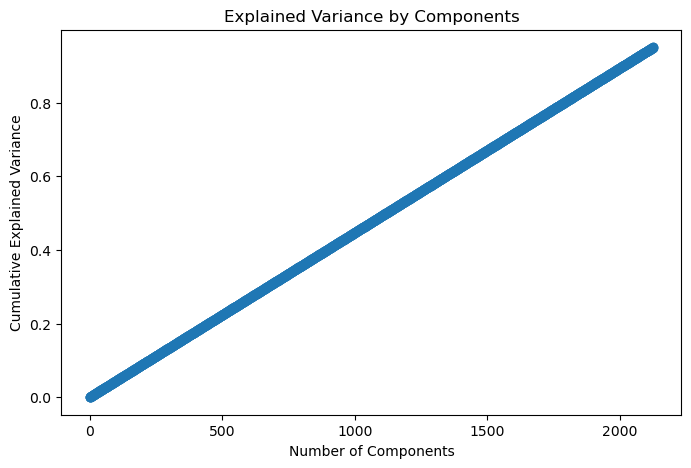

In [23]:
commulative_variance = np.cumsum(PCA_95.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(commulative_variance, marker='o', linestyle='--')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

**Visualizing Customer Clusters:** The clusters are visualized using two PCA components to understand the separation between customer groups.

In [24]:
PCA_2d = PCA(n_components=2)
x_pca_2d = PCA_2d.fit_transform(x_scaled)
PCA_2d_df = pd.DataFrame(data=x_pca_2d, columns=['PC1', 'PC2'])
print(PCA_2d_df)
print(x_pca_2d)

           PC1       PC2
0     0.721602  0.349564
1     0.107336 -0.122260
2     1.413577  0.533295
3     0.225558  1.905936
4    -0.755390  1.167542
...        ...       ...
2235 -1.244783 -0.969126
2236  0.255746  0.196347
2237  0.366834 -0.234854
2238  0.398546 -1.330292
2239  0.680830  0.335102

[2240 rows x 2 columns]
[[ 0.72160219  0.34956417]
 [ 0.1073361  -0.12225988]
 [ 1.41357741  0.53329539]
 ...
 [ 0.3668344  -0.23485365]
 [ 0.39854587 -1.3302919 ]
 [ 0.6808305   0.33510157]]


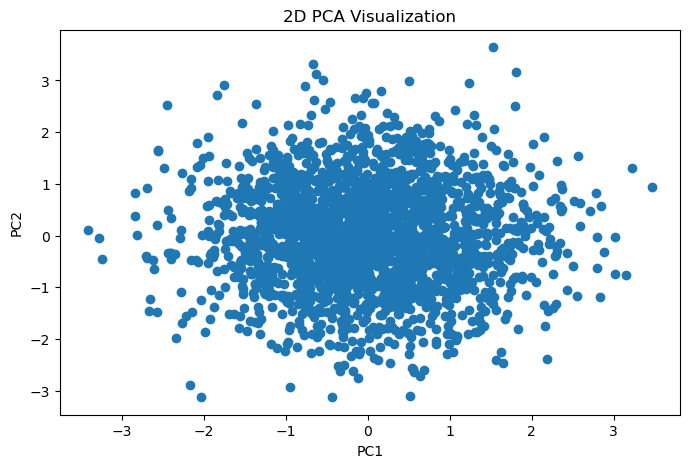

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(x=PCA_2d_df['PC1'], y=PCA_2d_df['PC2']) 
plt.title('2D PCA Visualization')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

**Elbow Method:** The Elbow Method helps us find the suitable number of clusters for K-Means.

In [27]:
WCSS = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    WCSS.append(kmeans.inertia_)

**Elbow Method Visualization:** This graph shows the WCSS values for different numbers of clusters.

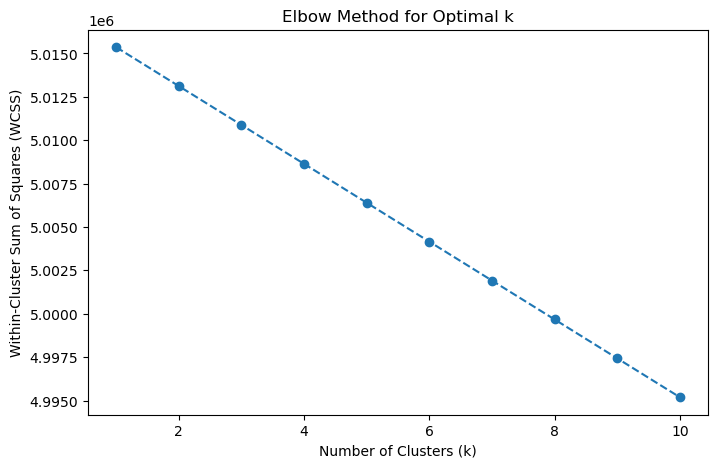

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, WCSS, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.show()

**Silhouette Score:** The Silhouette Score helps us measure how well the customers are separated into different clusters.

In [33]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=2, n_init=5)
    cluster_labels = kmeans.fit_predict(x_scaled)
    silhouette_avg = silhouette_score(x_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
print("silhouette_scores", silhouette_scores)
print(cluster_labels)

silhouette_scores [0.0001307559013005622, 0.00013075590128575754, 0.00013075590128038442, 0.00013075590128027627, 0.00013075590128568503, 0.00013075590128967752, 0.00013075590127883317, 0.00013075590128302985, 0.00013075590127878408]
[5 5 5 ... 5 5 5]


**Silhouette Score Visualization:** This graph compares the Silhouette Scores for different numbers of clusters.

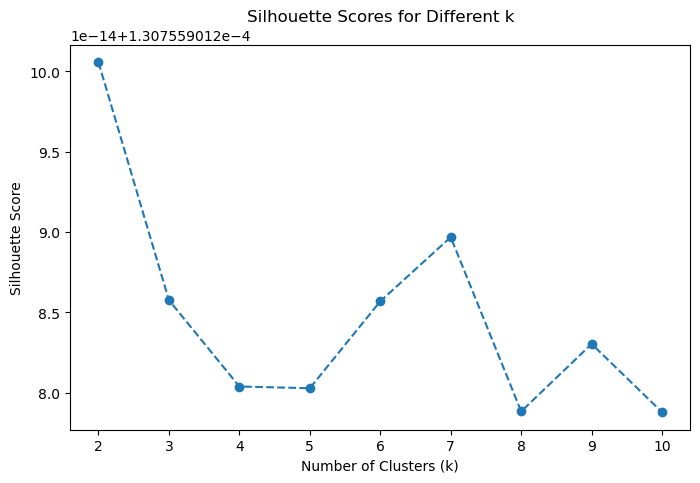

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

**Selecting the Best Number of Clusters:** The K value with the highest Silhouette Score is selected as the best number of clusters.

In [37]:
best_k = k_range[np.argmax(silhouette_scores)]  # +2 because range starts at 2
print("Best_k:", best_k)
best_score = max(silhouette_scores)
print("Best Silhouette Score:", best_score)

Best_k: 1
Best Silhouette Score: 0.0001307559013005622


**Applying K-Means Clustering:** K-Means is applied to divide customers into groups based on their similarities.

In [38]:
final_kmeans = KMeans(n_clusters=best_k, random_state=2, n_init=5)
cluster_labels = final_kmeans.fit_predict(x_pca)

**Assigning Cluster Labels:** Each customer is assigned to a cluster based on the K-Means results.

In [39]:
df['Cluster'] = cluster_labels
df.head(2)

,ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse,Cluster
0,5524\t1957\tGraduation\tSingle\t58138\t0\t0\t0...,0
1,2174\t1954\tGraduation\tSingle\t46344\t1\t1\t0...,0


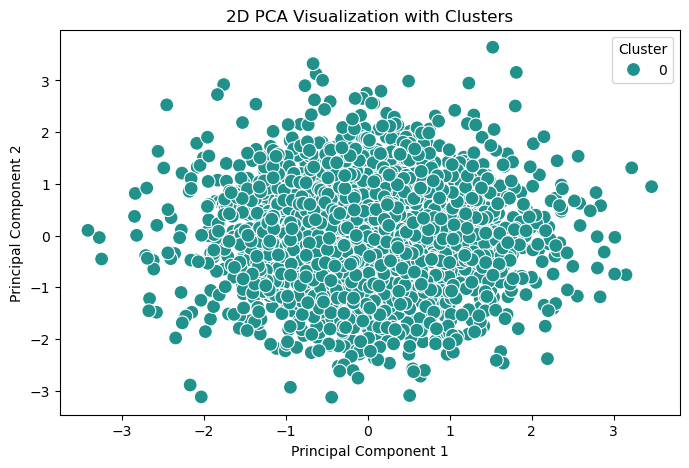

In [40]:
pca_df = pd.DataFrame(data=x_pca_2d, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels
plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=100)
plt.title('2D PCA Visualization with Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

**Analyzing Customer Clusters:** We analyze the average characteristics of each cluster to understand the behavior of different customer groups.

In [41]:
df.groupby('Cluster').mean(numeric_only=True)

""
Cluster
0


**Checking Cluster Sizes:** We check the number of customers in each cluster.

In [42]:
df['Cluster'].value_counts().sort_index()

Cluster
0    2240
Name: count, dtype: int64

**Conclusion:** This project used PCA and K-Means clustering to identify different customer segments. The Elbow Method and Silhouette Score helped select the suitable number of clusters. Finally, the clusters were converted into useful customer personas for business decision-making.